In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("CC GENERAL.csv")

In [3]:
df.shape

(8950, 18)

In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [6]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

In [7]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [10]:
df.drop(columns=["CUST_ID"], inplace=True)
print(f'list{df.columns}')

listIndex(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')


In [11]:
#Scaling of features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
silhouette_values = []
k_range = range(2,11)

for k in k_range:
    km = KMeans(n_clusters=k , init="k-means++" , n_init= 10 , random_state= 42)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    sil = silhouette_score(X_scaled , km.labels_ , sample_size=3000 , random_state=42)
    silhouette_values.append(sil)
    print(f"  k={k:2d}  |  Inertia={km.inertia_:>12,.1f}  |  Silhouette={sil:.4f}")

  k= 2  |  Inertia=   127,784.5  |  Silhouette=0.2143
  k= 3  |  Inertia=   111,975.0  |  Silhouette=0.2400
  k= 4  |  Inertia=    99,061.9  |  Silhouette=0.1965
  k= 5  |  Inertia=    91,490.5  |  Silhouette=0.1932
  k= 6  |  Inertia=    84,826.6  |  Silhouette=0.2038
  k= 7  |  Inertia=    79,856.2  |  Silhouette=0.2100
  k= 8  |  Inertia=    74,484.9  |  Silhouette=0.2233
  k= 9  |  Inertia=    69,828.7  |  Silhouette=0.2255
  k=10  |  Inertia=    66,466.4  |  Silhouette=0.2203


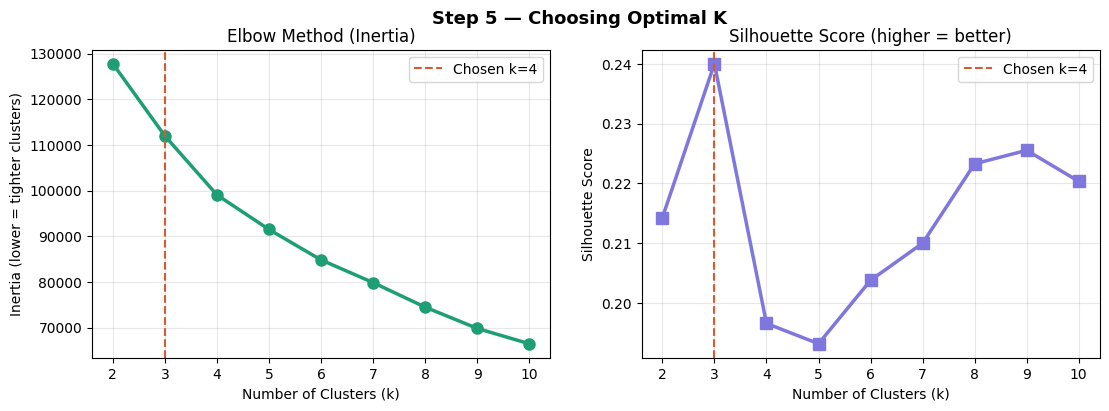

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Step 5 — Choosing Optimal K", fontsize=13, fontweight="bold")
 
# Elbow
axes[0].plot(list(k_range), inertia_values, "o-", color="#1D9E75", linewidth=2.5, markersize=8)
axes[0].axvline(x=3, color="#D85A30", linestyle="--", linewidth=1.5, label="Chosen k=4")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (lower = tighter clusters)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# Silhouette
axes[1].plot(list(k_range), silhouette_values, "s-", color="#7F77DD", linewidth=2.5, markersize=8)
axes[1].axvline(x=3, color="#D85A30", linestyle="--", linewidth=1.5, label="Chosen k=4")
axes[1].set_title("Silhouette Score (higher = better)")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

In [18]:
k_optimal  = 3

kmeans_final = KMeans(n_clusters=k_optimal , init="k-means++" , n_init= 10 , random_state= 42)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)
 
final_silhouette = silhouette_score(X_scaled, df["Cluster"], sample_size=3000, random_state=42)
print(f"  Optimal k         : {k_optimal}")
print(f"  Silhouette Score  : {final_silhouette:.4f}  (range -1 to 1; closer to 1 is better)")
print(f"\n  Cluster sizes:")
print(df["Cluster"].value_counts().sort_index().to_string())

  Optimal k         : 3
  Silhouette Score  : 0.2400  (range -1 to 1; closer to 1 is better)

  Cluster sizes:
Cluster
0    1275
1    6114
2    1561


In [19]:
feature_cols = [c for c in df.columns if c != "Cluster"]
cluster_means = df.groupby("Cluster")[feature_cols].mean().round(2)
 
print(cluster_means.to_string())

         BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  TENURE
Cluster                                                                                                                                                                                                                                                                                                               
0        2182.35               0.98    4187.02           2664.00                 1523.49        449.75                 0.95                        0.66                              0.74                    0.06              1.51          55.69       7642.78   4075.53           1227.92              0.30   11.92
1         807.72               0.83     496.06            247.27   

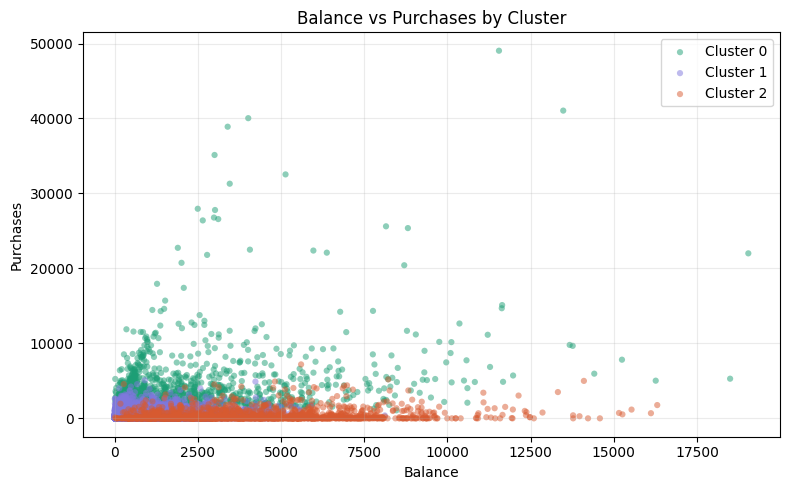

In [20]:
cluster_names = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2"
}
COLORS = {0: "#1D9E75", 1: "#7F77DD", 2: "#D85A30"}

plt.figure(figsize=(8, 5))
for cid in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == cid]
    plt.scatter(subset["BALANCE"], subset["PURCHASES"],
                c=COLORS[cid], label=cluster_names[cid],
                alpha=0.5, s=20, edgecolors="none")

plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("Balance vs Purchases by Cluster")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("graph1_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

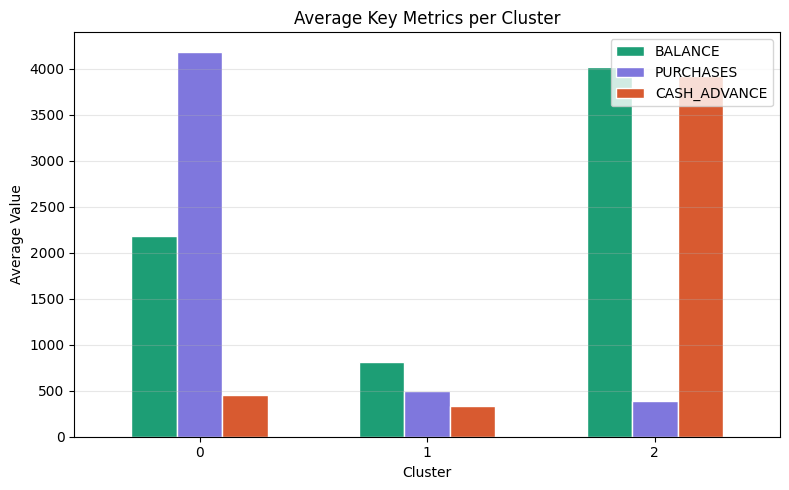

In [21]:
key_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE"]
cluster_avg = df.groupby("Cluster")[key_cols].mean()

cluster_avg.plot(kind="bar", figsize=(8, 5), color=["#1D9E75", "#7F77DD", "#D85A30"],
                 edgecolor="white", width=0.6)

plt.title("Average Key Metrics per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("graph2_bar.png", dpi=150, bbox_inches="tight")
plt.show()

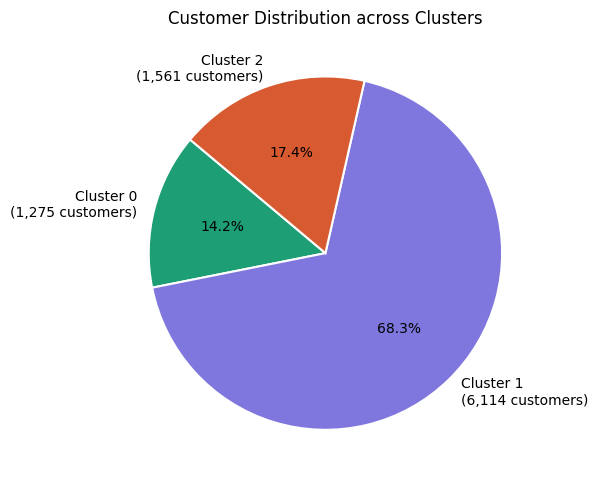

In [22]:
cluster_counts = df["Cluster"].value_counts().sort_index()
labels = [f"Cluster {i}\n({v:,} customers)" for i, v in cluster_counts.items()]

plt.figure(figsize=(6, 6))
plt.pie(cluster_counts, labels=labels,
        autopct="%1.1f%%",
        colors=["#1D9E75", "#7F77DD", "#D85A30"],
        startangle=140,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})

plt.title("Customer Distribution across Clusters")
plt.tight_layout()
plt.savefig("graph3_pie.png", dpi=150, bbox_inches="tight")
plt.show()

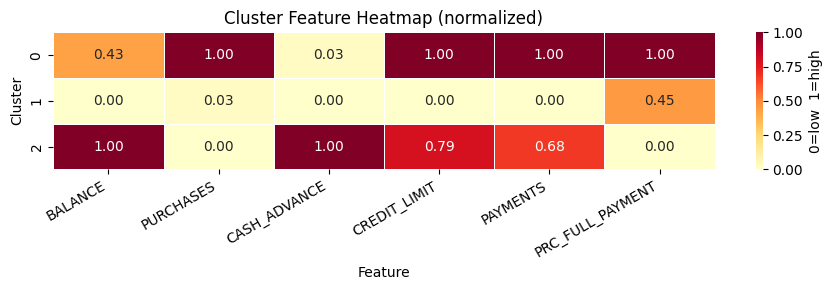

In [23]:
key_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE",
            "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT"]
cluster_means = df.groupby("Cluster")[key_cols].mean()

# Normalize 0 to 1 so all features are on the same scale
normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

plt.figure(figsize=(9, 3))
sns.heatmap(normalized, annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.5, linecolor="white",
            cbar_kws={"label": "0=low  1=high"})

plt.title("Cluster Feature Heatmap (normalized)")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("graph4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
import pickle

# Save model + scaler together
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump({"model": kmeans_final, "scaler": scaler}, f)

print("Saved: kmeans_model.pkl")

# Load it back
with open("kmeans_model.pkl", "rb") as f:
    saved = pickle.load(f)

kmeans_loaded = saved["model"]
scaler_loaded  = saved["scaler"]

print("Model loaded successfully")
print(f"  Clusters : {kmeans_loaded.n_clusters}")
print(f"  Features : {kmeans_loaded.n_features_in_}")

# Test — predict cluster for a new customer
test_customer = pd.DataFrame([{
    "BALANCE": 1500, "BALANCE_FREQUENCY": 0.9,
    "PURCHASES": 300, "ONEOFF_PURCHASES": 100,
    "INSTALLMENTS_PURCHASES": 200, "CASH_ADVANCE": 0,
    "PURCHASES_FREQUENCY": 0.5, "ONEOFF_PURCHASES_FREQUENCY": 0.2,
    "PURCHASES_INSTALLMENTS_FREQUENCY": 0.4, "CASH_ADVANCE_FREQUENCY": 0.0,
    "CASH_ADVANCE_TRX": 0, "PURCHASES_TRX": 5,
    "CREDIT_LIMIT": 3000, "PAYMENTS": 400,
    "MINIMUM_PAYMENTS": 200, "PRC_FULL_PAYMENT": 0.1,
    "TENURE": 12
}])

test_scaled    = scaler_loaded.transform(test_customer)
predicted      = kmeans_loaded.predict(test_scaled)
print(f"\nTest customer → Cluster {predicted[0]}")

Saved: kmeans_model.pkl
Model loaded successfully
  Clusters : 3
  Features : 17

Test customer → Cluster 1
